In [1]:
suppressMessages({
    require(Seurat)
    library(Matrix)
    require(dplyr)  
})

In [2]:
N4_glia <- readRDS('../../13.case_analysis/4.amphi_glia_evo_devo/3.monocle3_lineage/3.subset_glia/N4_glia.rds')
T1_glia <- readRDS('../../13.case_analysis/4.amphi_glia_evo_devo/3.monocle3_lineage/3.subset_glia/T1_glia.rds')

In [3]:
N4_glia@meta.data$Barcodes <- paste(N4_glia@meta.data$orig.ident, N4_glia@meta.data$Barcodes, sep = "_")
T1_glia@meta.data$Barcodes <- paste(T1_glia@meta.data$orig.ident, T1_glia@meta.data$Barcodes, sep = "_")
N4_glia <- RenameCells(N4_glia, new.names = N4_glia@meta.data$Barcodes)
T1_glia <- RenameCells(T1_glia, new.names = T1_glia@meta.data$Barcodes)

In [4]:
rds.list <- list(N4_glia, T1_glia)
rds.list <- lapply(rds.list, function(obj) {
    obj <- NormalizeData(obj, normalization.method = "LogNormalize", verbose = FALSE)
    obj <- FindVariableFeatures(obj, selection.method = "vst", nfeatures = 3000)
    obj <- ScaleData(obj, verbose = FALSE)
    obj <- RunPCA(obj, verbose = FALSE)
    obj <- RunUMAP(obj, dims = 1:30, reduction = "pca") %>% 
        FindNeighbors(reduction = "pca", dims = 1:30) %>%
        FindNeighbors(reduction = "pca", dims = 1:30) %>%
        FindClusters(resolution = 1)
    return(obj)
})

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
16:20:10 UMAP embedding parameters a = 0.9922 b = 1.112

16:20:10 Read 4214 rows and found 30 numeric columns

16:20:10 Using Annoy for neighbor search, n_neighbors = 30

16:20:10 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

16:20:11 Writing NN index file to temp file /tmp/RtmpzWrrWQ/file9418142e49ba

16:20:11 Searching Annoy index using 1 thread, search_k = 3000

16:20:13 Annoy recall = 100%

16:20:14 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors =

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 4214
Number of edges: 158414

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7927
Number of communities: 14
Elapsed time: 0 seconds


16:21:05 UMAP embedding parameters a = 0.9922 b = 1.112

16:21:05 Read 4829 rows and found 30 numeric columns

16:21:05 Using Annoy for neighbor search, n_neighbors = 30

16:21:05 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

16:21:06 Writing NN index file to temp file /tmp/RtmpzWrrWQ/file94181e9b2a6f

16:21:06 Searching Annoy index using 1 thread, search_k = 3000

16:21:08 Annoy recall = 100%

16:21:08 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

16:21:10 Initializing from normalized Laplacian + noise (using RSpectra)

16:21:10 Commencing optimization for 500 epochs, with 199908 positive edges

16:21:32 Optimization finished

Computing nearest neighbor graph

Computing SNN

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 4829
Number of edges: 177143

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8526
Number of communities: 21
Elapsed time: 0 seconds


In [5]:
N4 <- readRDS('../4.RNA_velocity/N4_glia.velocyte.rds')
T1 <- readRDS('../4.RNA_velocity/T1_glia.velocyte.rds')

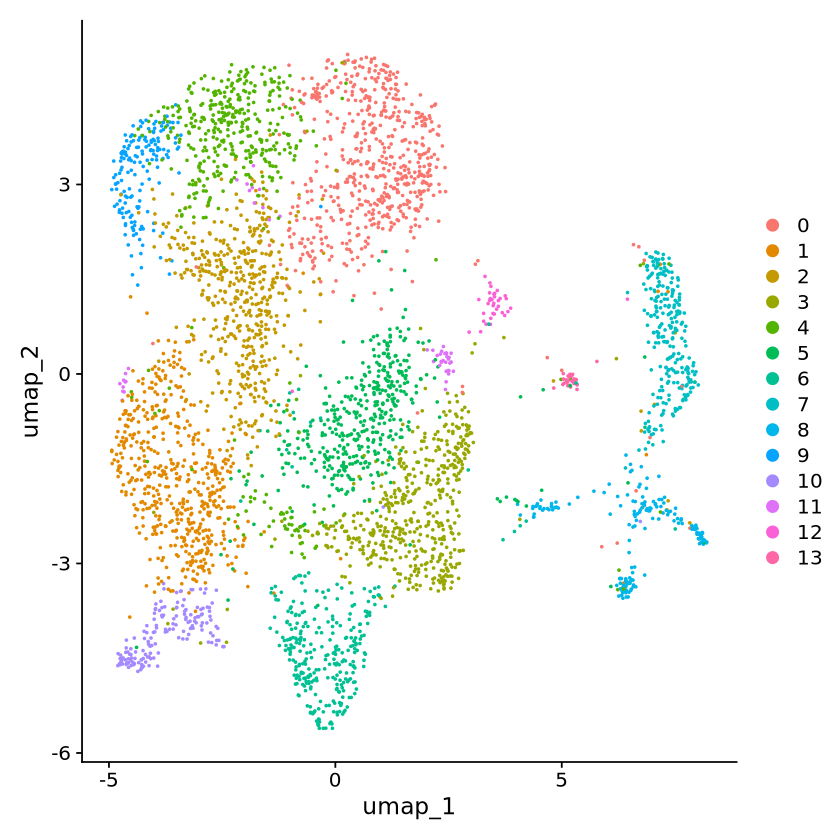

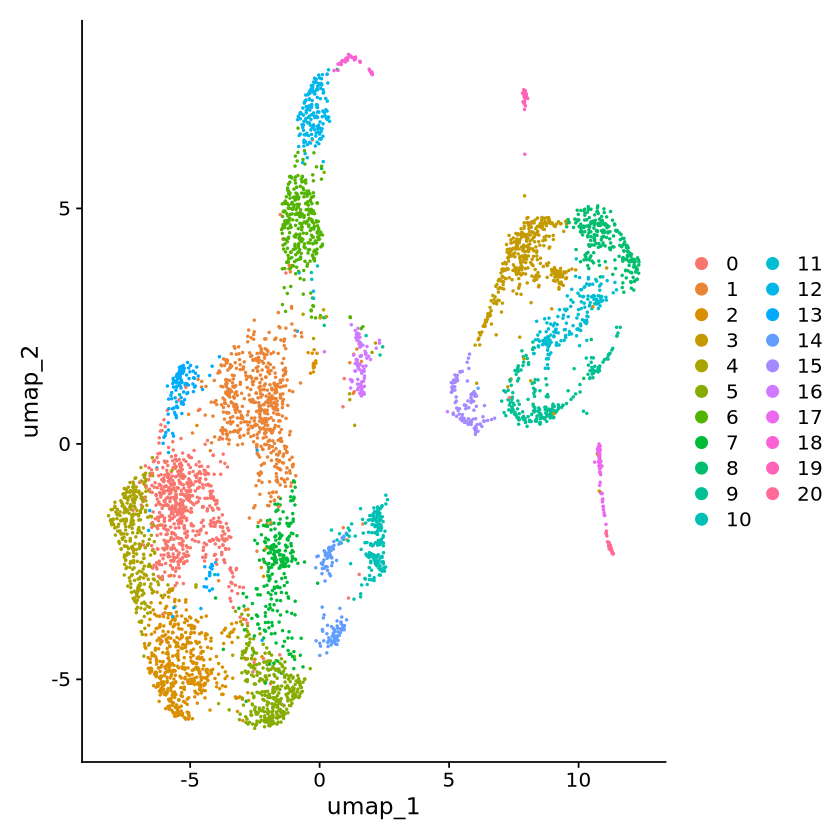

In [6]:
N4_glia <- rds.list[[1]]
T1_glia <- rds.list[[2]]
DimPlot(N4_glia)
DimPlot(T1_glia)

In [7]:
N4_glia[["RNA"]] <- as(N4_glia[["RNA"]], "Assay")
sceasy::convertFormat(N4_glia, main_layer = "count", from="seurat", to="anndata",
                       outFile='Bflo.N4_glia.h5ad')
T1_glia[["RNA"]] <- as(T1_glia[["RNA"]], "Assay")
sceasy::convertFormat(T1_glia, main_layer = "count", from="seurat", to="anndata",
                       outFile='Bflo.T1_glia.h5ad')

Warning message in .regularise_df(obj@meta.data, drop_single_values = drop_single_values):
“Dropping single category variables:Predicted_doublets, cellgroup, stage”


AnnData object with n_obs × n_vars = 4214 × 21243
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Barcodes', 'Doubletscore', 'Percent.Largest.Gene', 'seurat_clusters', 'celltype', 'cellcluster', 'RNA_snn_res.1'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    obsm: 'X_pca', 'X_umap', 'X_tsne'

Warning message in .regularise_df(obj@meta.data, drop_single_values = drop_single_values):
“Dropping single category variables:Predicted_doublets, cellgroup, stage”


AnnData object with n_obs × n_vars = 4829 × 22188
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Barcodes', 'Doubletscore', 'Percent.Largest.Gene', 'seurat_clusters', 'celltype', 'cellcluster', 'RNA_snn_res.1'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    obsm: 'X_pca', 'X_umap', 'X_tsne'

In [10]:
# write Seurat format spliced and unspliced information to mtx and tsv, which will be incoporated into h5ad format for scvelo analysis
write_velo_info <- function(obj, name){
    spliced_mat <- GetAssayData(obj, assay = "spliced", layer = "counts")
    unspliced_mat <- GetAssayData(obj, assay = "unspliced", layer = "counts")
    
    Matrix::writeMM(spliced_mat, file = paste0(name, ".spliced.mtx"))
    Matrix::writeMM(unspliced_mat, file = paste0(name, ".unspliced.mtx"))
    
    write.table(rownames(spliced_mat), file = paste0(name, ".genes.tsv"),
                row.names = FALSE, quote=FALSE, col.names = FALSE)
    write.table(colnames(spliced_mat), file = paste0(name, "barcodes.tsv"),
                row.names = FALSE, quote=FALSE, col.names = FALSE)
}

In [11]:
write_velo_info(N4, 'N4_glia_velo')
write_velo_info(T1, 'T1_glia_velo')